In [647]:
#Import Libraries
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [648]:
#Read CSV file for Analysis
df = pd.read_csv('samsung_global_sales_dataset.csv')

In [649]:
#Preview Data
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [650]:
#Statistical Summary of Data
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


In [651]:
#Data Summary/Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [652]:
#Filling empty spaces
df.sort_values(by=['year','sale_date'])
df['storage']=df['storage'].bfill()

In [653]:
#Shape of Data
df.shape

(15500, 28)

In [654]:
#Sort values by year and fill backward the missing values
df.sort_values(by=['sale_date'], ascending=False)
df['previous_device_os']=df['previous_device_os'].bfill()
df['previous_device_os']

0            Feature Phone
1            Feature Phone
2                 New User
3          Android (Other)
4          Android (Other)
               ...        
15495    Android (Samsung)
15496                  iOS
15497                  iOS
15498                  iOS
15499                  iOS
Name: previous_device_os, Length: 15500, dtype: object

In [655]:
#Calculate the median of customer rating
customer_rating_median=df['customer_rating'].median()
customer_rating_median

np.float64(3.7)

In [656]:
#Fill in missing values in customer rating with its median
df['customer_rating']=df['customer_rating'].fillna(customer_rating_median)
df['customer_rating']

0        3.2
1        3.7
2        3.5
3        4.0
4        3.0
        ... 
15495    4.0
15496    3.7
15497    3.7
15498    3.3
15499    4.9
Name: customer_rating, Length: 15500, dtype: float64

In [657]:
#Current Data Structure
#No missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 15500 non-null  object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [658]:
#Missing/ Incomplete Data
missing_values = df.isnull().sum()
missing_values

#There are no missing values now

sale_id                   0
sale_date                 0
year                      0
quarter                   0
month                     0
country                   0
region                    0
city                      0
product_name              0
category                  0
storage                   0
color                     0
is_5g                     0
unit_price_usd            0
discount_pct              0
units_sold                0
discounted_price_usd      0
revenue_usd               0
currency                  0
fx_rate_to_usd            0
revenue_local_currency    0
sales_channel             0
payment_method            0
customer_segment          0
customer_age_group        0
previous_device_os        0
customer_rating           0
return_status             0
dtype: int64

In [659]:
#Duplicate Values
df.duplicated().sum()

#No Duplicate Values

np.int64(0)

In [660]:
#Statistical Summary after Cleaning Data
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,15500.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.731581
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.614742
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.400000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.100000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


In [661]:
df.shape

(15500, 28)

In [662]:
#Business Problem and Questions to ask

#How can the company increase smartphone sales and revenue across regions, products, and customer segments?

#This dataset can help the business understand:

#Which products sell the most
#Which regions generate the most revenue
#Which customer segments buy more
#Whether discounts increase sales
#Which sales channels perform best
#Whether returns or low ratings affect revenue

In [663]:
#Calculate Total Sales
df['Total Sales'] = df['units_sold'] * df['unit_price_usd']

In [664]:
df['revenue_usd']

0         1246.77
1         1457.72
2         2165.82
3          728.07
4         3125.96
           ...   
15495      476.87
15496    14371.35
15497      560.54
15498      162.56
15499     1418.25
Name: revenue_usd, Length: 15500, dtype: float64

In [665]:
#Total Revenue
total_revenue = df['revenue_usd'].sum()
total_revenue

np.float64(22911258.880000003)

In [666]:
#Total Quantity Sold
total_quantity_sold = df['units_sold'].sum()
total_quantity_sold

np.int64(36580)

In [667]:
#Revenue by Product Name
revenue_by_product_name=df.groupby('product_name')['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_product_name.head(10)

product_name
Samsung Neo QLED 8K QN900C          2231009.59
Samsung OLED S95C 65-inch           1222086.81
Samsung French Door Refrigerator     914370.15
Samsung Neo QLED 4K QN85C            859697.30
Samsung Galaxy Z Fold 5              858492.72
Samsung Galaxy Z Fold 4              763137.30
Samsung ViewFinity S9                746484.03
Samsung Odyssey Neo G9               651827.53
Samsung The Frame 55-inch            618187.82
Samsung Galaxy Tab S9 Ultra          613184.18
Name: revenue_usd, dtype: float64

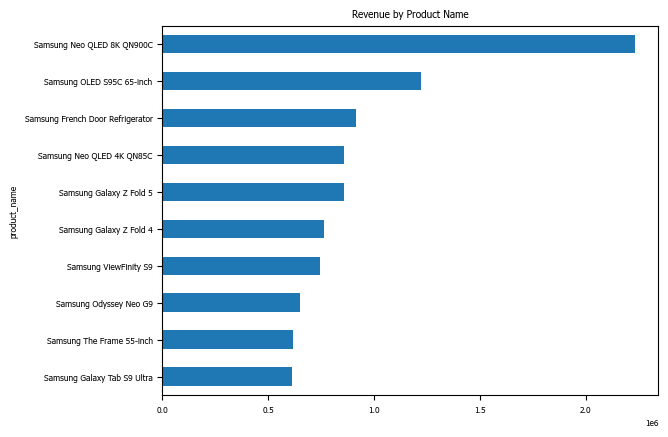

In [668]:
#Top 10 Products that made the most Revenue
revenue_by_product_name2 = df.groupby('product_name')['revenue_usd'].sum().sort_values(ascending=False).head(10).sort_values()

revenue_by_product_name2.plot(kind='barh')
plt.title('Revenue by Product Name')
plt.show()

In [669]:
#Revenue by Region
revenue_by_region=df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False).head(10)
revenue_by_region

region
Europe           7903104.02
Asia             6732880.38
Africa           2223891.75
South America    2119745.70
North America    1363648.44
Middle East       887007.49
Europe/Asia       866429.72
Oceania           814551.38
Name: revenue_usd, dtype: float64

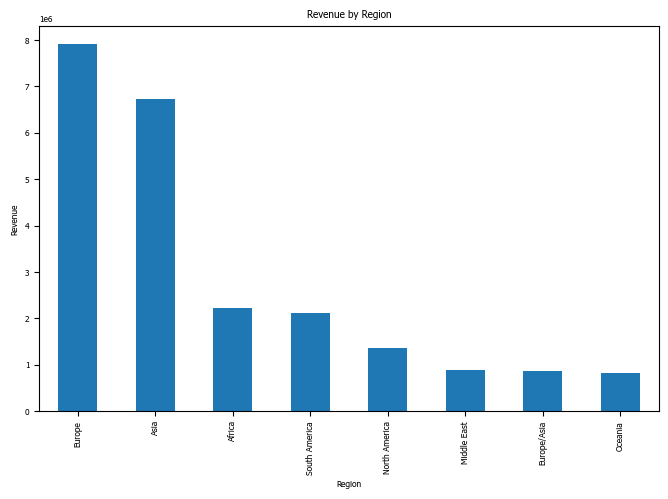

In [670]:
revenue_by_region.plot(kind='bar',title='Revenue by Region', figsize=(8,5))
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

In [671]:
#Visualizing Revenue by Region on a Map
import plotly.io as pio
pio.renderers.default='browser'
fig=px.choropleth(df,
                  locations='region',
                  locationmode='ISO-3',
                  color='revenue_usd',
                  hover_data=['revenue_usd'],
                  projection='natural earth',
                  color_continuous_scale=px.colors.sequential.Plasma)

fig.show()

In [672]:
#Revenue by Region and Product Name
revenue_by_region_and_product_name=df.groupby(['region','product_name'])['revenue_usd'].sum().sort_values(ascending=False).head(10)
revenue_by_region_and_product_name


region  product_name                    
Europe  Samsung Neo QLED 8K QN900C          904234.70
Asia    Samsung Neo QLED 8K QN900C          643138.29
        Samsung OLED S95C 65-inch           412849.01
Europe  Samsung OLED S95C 65-inch           368822.89
Asia    Samsung French Door Refrigerator    302660.33
Europe  Samsung Galaxy Z Fold 5             299929.38
        Samsung Galaxy Z Fold 4             299364.92
        Samsung French Door Refrigerator    298572.06
Asia    Samsung ViewFinity S9               269957.83
Europe  Samsung Neo QLED 4K QN85C           255087.61
Name: revenue_usd, dtype: float64

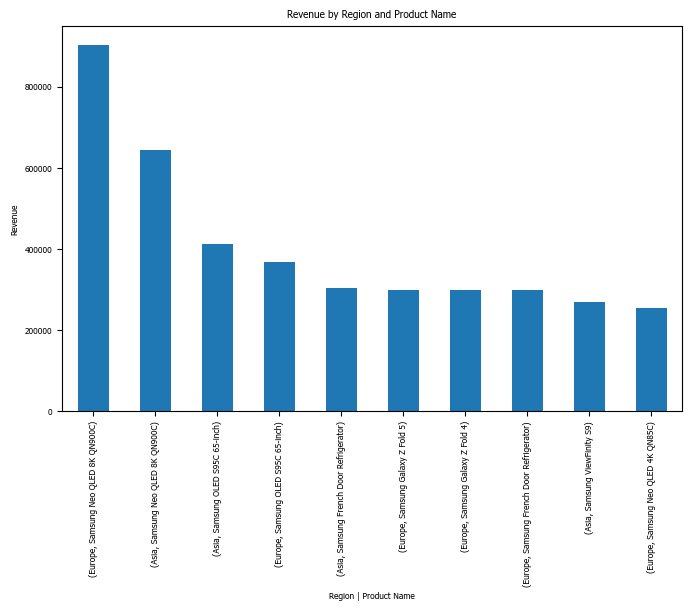

In [673]:
#Visualization of Revenue by Region and Product Name(Top_10)
revenue_by_region_and_product_name.plot(kind='bar', stacked=True,title='Revenue by Region and Product Name', figsize=(8,5))
plt.xlabel('Region | Product Name')
plt.ylabel('Revenue')
plt.show()

In [674]:
#Revenue by Category
revenue_by_category=df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)
top_5=revenue_by_category.head(5)
top_5

category
Smart TV      5559342.55
Galaxy S      4728112.37
Galaxy Z      2765867.41
Galaxy Tab    2451712.69
Appliances    2253734.40
Name: revenue_usd, dtype: float64

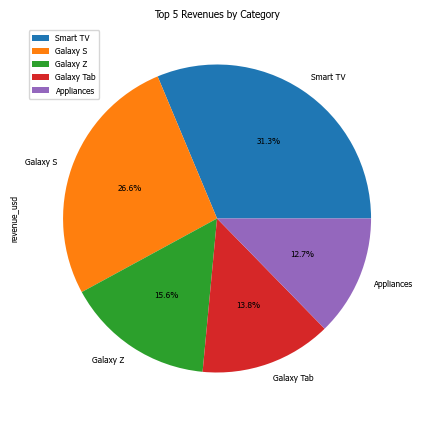

In [702]:
#Visualization of Top 5 Categories the yielded the most revenue
top_5.plot(kind='pie', figsize=(8,5), legend=True, title='Top 5 Revenues by Category',labels=top_5.index, autopct='%1.1f%%')
plt.show()

In [676]:
#Revenue by Product Name and Category
df.groupby(['category', 'product_name'])['revenue_usd'].sum().sort_values(ascending=False).head(10)

category    product_name                    
Smart TV    Samsung Neo QLED 8K QN900C          2231009.59
            Samsung OLED S95C 65-inch           1222086.81
Appliances  Samsung French Door Refrigerator     914370.15
Smart TV    Samsung Neo QLED 4K QN85C            859697.30
Galaxy Z    Samsung Galaxy Z Fold 5              858492.72
            Samsung Galaxy Z Fold 4              763137.30
Monitor     Samsung ViewFinity S9                746484.03
            Samsung Odyssey Neo G9               651827.53
Smart TV    Samsung The Frame 55-inch            618187.82
Galaxy Tab  Samsung Galaxy Tab S9 Ultra          613184.18
Name: revenue_usd, dtype: float64

In [677]:
#Revenue by City
df.groupby('city')['revenue_usd'].sum().sort_values(ascending=False).head(10)

city
Singapore       387462.27
Islamabad       129982.32
Abu Dhabi       114474.74
Athens          113545.20
Zaporizhzhia    107020.00
Narayanganj     103767.67
Vejle           102435.96
Rhodes          100069.03
Bucharest        98553.27
Rayong           91349.71
Name: revenue_usd, dtype: float64

In [678]:
#Revenue by Sales Channel
df.groupby('sales_channel')['revenue_usd'].sum().sort_values(ascending=False)

sales_channel
Samsung Store           3432361.37
E-commerce Platform     3369992.99
Corporate / B2B         3346952.28
Third-Party Retailer    3285038.22
Carrier Store           3212142.04
Online (Samsung.com)    3155638.03
Authorized Reseller     3109133.95
Name: revenue_usd, dtype: float64

In [679]:
#Revenue by Month/Monthly Trend
revenue_by_month=df.groupby(['month'])['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_month

month
June         2099161.62
October      2096938.93
January      2044209.91
May          1959111.57
August       1942453.29
December     1933539.81
September    1866744.03
April        1850411.77
July         1841931.21
March        1827762.45
November     1808459.09
February     1640535.20
Name: revenue_usd, dtype: float64

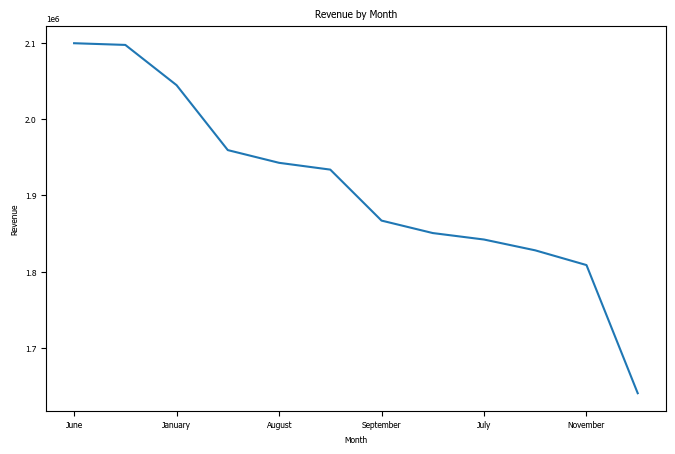

In [680]:
#Visualization of Revenue by Month/ Monthly Trend
revenue_by_month.plot(figsize=(8,5), title='Revenue by Month', kind='line')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [681]:
#Revenue by Year
revenue_by_year=df.groupby(['year'])['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_year

year
2023    5867029.62
2022    5760781.90
2024    5690410.53
2021    5593036.83
Name: revenue_usd, dtype: float64

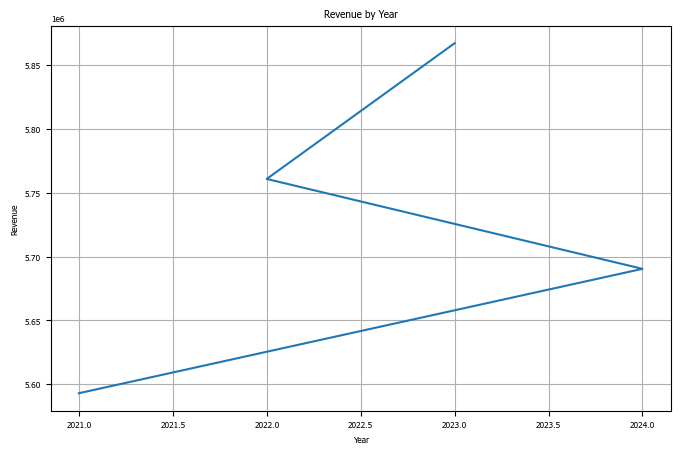

In [682]:
#Yearly Trend/Revenue by Year
revenue_by_year.plot(figsize=(8,5), title='Revenue by Year',kind='line', grid=True)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

In [683]:
#Revenue by Quarter
df.groupby('quarter')['revenue_usd'].sum().sort_values(ascending=False)

quarter
Q2    5908684.96
Q4    5838937.83
Q3    5651128.53
Q1    5512507.56
Name: revenue_usd, dtype: float64

In [684]:
#Revenue by Category and Units Sold(Quantity)
df.groupby('category')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False).head(10)

,units_sold,revenue_usd
category,,
Smart TV,2941,5559342.55
Galaxy S,5567,4728112.37
Galaxy Z,2436,2765867.41
Galaxy Tab,3706,2451712.69
Appliances,2508,2253734.40
Monitor,2486,2125195.20
Galaxy A,4498,1154772.22
Galaxy Watch,3453,913148.29
Galaxy M,2112,425853.53


In [685]:
#Revenue by Product Name and Units Sold(Quantity)
df.groupby('product_name')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False).head(10)

,units_sold,revenue_usd
product_name,,
Samsung Neo QLED 8K QN900C,476,2231009.59
Samsung OLED S95C 65-inch,518,1222086.81
Samsung French Door Refrigerator,542,914370.15
Samsung Neo QLED 4K QN85C,504,859697.30
Samsung Galaxy Z Fold 5,509,858492.72
Samsung Galaxy Z Fold 4,494,763137.30
Samsung ViewFinity S9,525,746484.03
Samsung Odyssey Neo G9,457,651827.53
Samsung The Frame 55-inch,507,618187.82


In [686]:
#Revenue for Discounts and Units Sold(Quantity)
df.groupby('discount_pct')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False).head(10)

,units_sold,revenue_usd
discount_pct,,
0,14053,9184498.64
2,2820,1874121.83
12,2858,1831191.59
3,2745,1811340.79
7,2824,1763321.83
5,2859,1721757.29
10,2819,1681115.12
15,2893,1673408.69
20,2709,1370503.10


In [687]:
#Revenue by Sales Channel
revenue_by_sales_channel=df.groupby('sales_channel')['revenue_usd'].sum().sort_values( ascending=False).sort_values()
revenue_by_sales_channel

sales_channel
Authorized Reseller     3109133.95
Online (Samsung.com)    3155638.03
Carrier Store           3212142.04
Third-Party Retailer    3285038.22
Corporate / B2B         3346952.28
E-commerce Platform     3369992.99
Samsung Store           3432361.37
Name: revenue_usd, dtype: float64

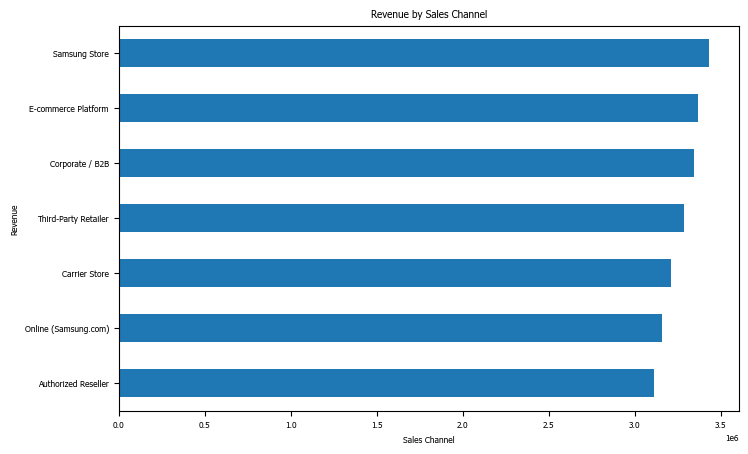

In [688]:
revenue_by_sales_channel.plot(figsize=(8,5), title='Revenue by Sales Channel', kind='barh')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue')
plt.show()

In [689]:
#Revenue by Customer Segment
customer_segment=df.groupby('customer_segment')['revenue_usd'].sum().sort_values(ascending=False)
customer_segment

customer_segment
Government    4748703.90
Individual    4643632.08
Business      4545605.07
Enterprise    4491693.89
Education     4481623.94
Name: revenue_usd, dtype: float64

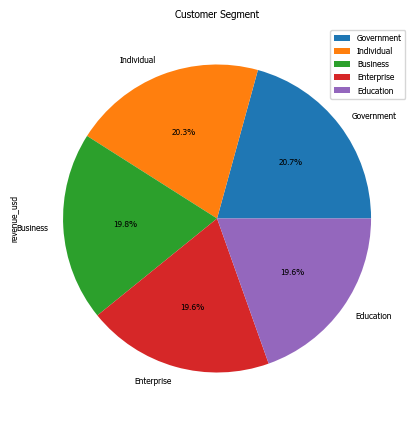

In [690]:
#Visualization Revenue by Customer Segment
customer_segment.plot(figsize=(8,5), title='Customer Segment',legend=True, kind='pie', labels=customer_segment.index, autopct='%1.1f%%')
#plt.autoscale(tight=True)
plt.show()

In [691]:
#Revenue by Customer Age Group, Units Sold and Product Name
customer_age_group_revenue=df.groupby('customer_age_group')[['revenue_usd','units_sold','product_name']].sum().sort_values(by= 'units_sold', ascending=False)
customer_age_group_revenue

,revenue_usd,units_sold,product_name
customer_age_group,,,
25–34,4855112.93,7665,Samsung Galaxy A34 5GSamsung Galaxy Watch 5Sam...
55+,4610312.16,7343,Samsung Galaxy S23Samsung T55 27-inch FHDSamsu...
45–54,4400631.02,7228,Samsung Galaxy Tab S9 UltraSamsung Galaxy Buds...
35–44,4592785.44,7178,Samsung Galaxy S22Samsung Galaxy Tab S9+Samsun...
18–24,4452417.33,7166,Samsung Galaxy Buds LiveSamsung Galaxy M14 5GS...


In [692]:
#Revenue by Product Name and Customer Rating
df.groupby('product_name')['customer_rating'].mean().sort_values(ascending=False)

product_name
Samsung Neo QLED 4K QN85C         3.839819
Samsung Galaxy A04                3.825000
Samsung Galaxy M14 5G             3.820976
Samsung Galaxy S23 FE             3.811207
Samsung T7 Shield 1TB SSD         3.810628
                                    ...   
Samsung Galaxy Tab S9 FE          3.669600
Samsung Galaxy Z Fold 4           3.665641
Samsung Galaxy Watch 4 Classic    3.654902
Samsung Galaxy M54 5G             3.654028
Samsung Galaxy Tab A9+            3.651570
Name: customer_rating, Length: 73, dtype: float64

In [693]:
#Return Status by Product Name
df.groupby('product_name')['return_status'].value_counts()

product_name                     return_status
Samsung 11kg Washer-Dryer Combo  Kept             163
                                 Returned          26
                                 Exchanged         12
Samsung 256GB MicroSD Card       Kept             163
                                 Returned          28
                                                 ... 
Samsung WindFree AC 1.5 Ton      Returned          14
                                 Exchanged         12
Samsung Wireless Charger Pad     Kept             196
                                 Returned          26
                                 Exchanged         11
Name: count, Length: 219, dtype: int64

In [694]:
#Forecasting

#create yearly revenue dataframe
df_year=df.groupby('year')['revenue_usd'].sum().reset_index()

df_year.columns=['ds','y'] #Prophet format
df_year['ds']=pd.to_datetime(df_year['ds'],format='%Y')
#df_year['y']=pd.to_datetime(df_year['y'])
print(df_year.head())



          ds           y
0 2021-01-01  5593036.83
1 2022-01-01  5760781.90
2 2023-01-01  5867029.62
3 2024-01-01  5690410.53


In [695]:
#Convert dates to numeric
df_year['year_num']=df_year['ds'].dt.year

X=df_year[['year_num']]
y=df_year['y']

model=LinearRegression()
model.fit(X,y)


#Predict Next Year
future_year=np.array([[2025]])
forecast_2025=model.predict(future_year)

print('Forecast Revenue for 2025:', forecast_2025[0])

Forecast Revenue for 2025: 5827406.924999997


/Users/pascalobeng-poku/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


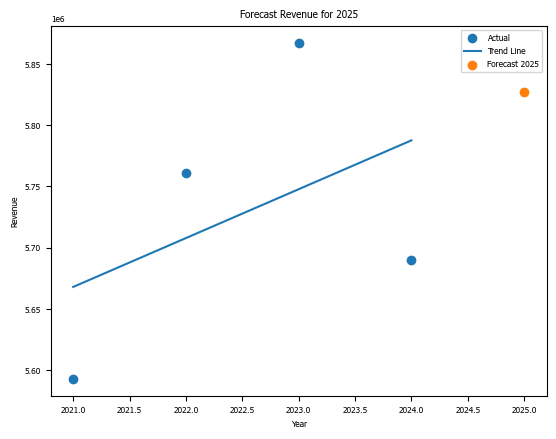

In [696]:
#Forecast with Linear Regression
plt.scatter(df_year['year_num'],y,label='Actual')
plt.plot(df_year['year_num'],model.predict(X),label='Trend Line')

#Add forecast point
plt.scatter(2025,forecast_2025,label='Forecast 2025')

plt.title('Forecast Revenue for 2025')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend()
plt.show()

In [697]:
#Forecast with Prophet
model=Prophet()
model.fit(df_year)

future=model.make_future_dataframe(periods=12,freq='ME')
forecast_2025=model.predict(future)
print('Forecast Revenue for 2025:', forecast_2025.head(1))


23:50:33 - cmdstanpy - INFO - Chain [1] start processing
23:50:38 - cmdstanpy - INFO - Chain [1] done processing


Forecast Revenue for 2025:           ds         trend    yhat_lower    yhat_upper   trend_lower  \
0 2021-01-01  2.296741e+07  5.593037e+06  5.593037e+06  2.296741e+07   

    trend_upper  additive_terms  additive_terms_lower  additive_terms_upper  \
0  2.296741e+07   -1.737437e+07         -1.737437e+07         -1.737437e+07   

         yearly  yearly_lower  yearly_upper  multiplicative_terms  \
0 -1.737437e+07 -1.737437e+07 -1.737437e+07                   0.0   

   multiplicative_terms_lower  multiplicative_terms_upper          yhat  
0                         0.0                         0.0  5.593037e+06  


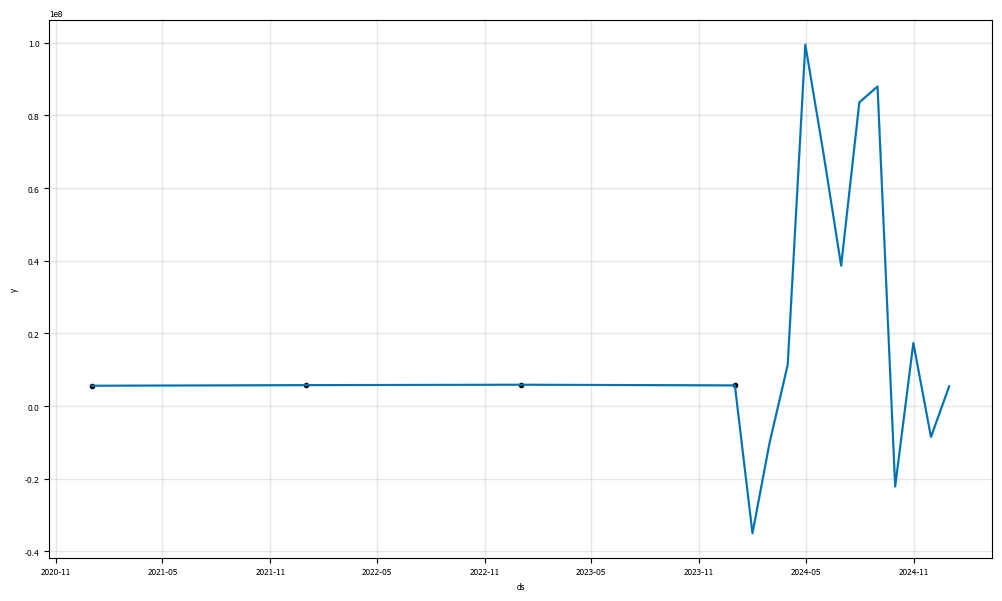

In [698]:
#Plot forecast
model.plot(forecast_2025)
plt.show()

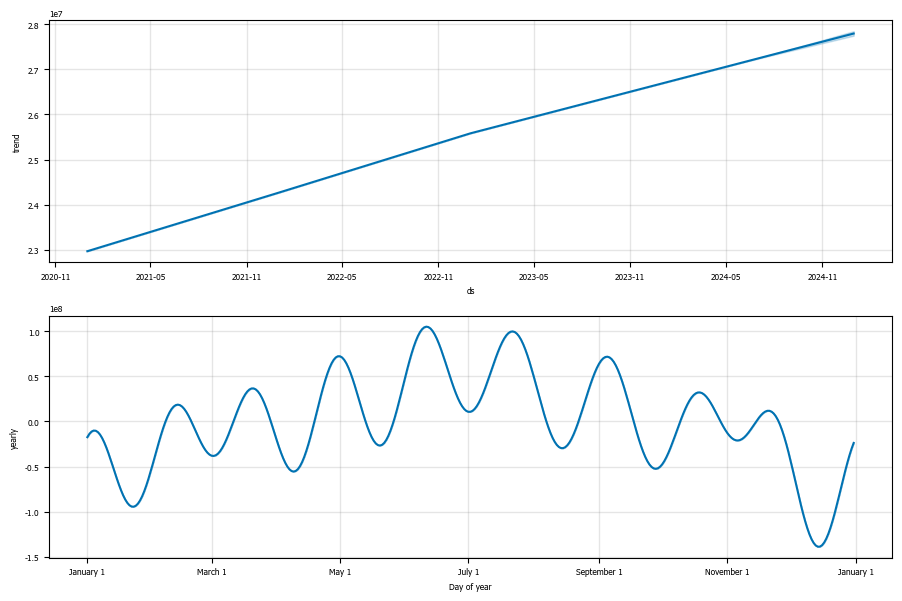

In [699]:
#Plot Components for Trends/ Seasonality
model.plot_components(forecast_2025)
plt.show()

In [701]:
df.to_csv('Retail Sales Forecasting-Samsung-Cleaned.csv', index=False)